# SuppFig — germline (gnomAD) decontamination of scNanoSeq cells

Per-cell fraction of unfiltered variant calls removed when filtering against gnomAD at a range of population-allele-frequency (popAF) thresholds, for scNanoSeq breast tumour samples. Curves are drawn per sample and split into tumour vs non-tumour cells; dot colour encodes each cell's total number of called mutations.

Inputs (precomputed, in `data/SuppFig_germline_decontamination/`):
- `germline_decontamination_stats.csv` — per cell × threshold: `n_vars`, `n_nongnomad_vars`.
- `sample_ID_mapping_dg_annot_tumor_cells.txt` — tumour-cell annotation per sample.

In [1]:
# --- Nature figure style: 0.25 lw spines/ticks, no top/right spines, embedded fonts ---
import matplotlib as mpl
mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42, "font.family": "sans-serif", "font.size": 8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.25,
    "xtick.major.width": 0.25, "ytick.major.width": 0.25,
    "xtick.minor.width": 0.25, "ytick.minor.width": 0.25,
    "xtick.labelsize": 7, "ytick.labelsize": 7,
})

def nature_axes(ax, keep_top=False):
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(keep_top)
    for sp in ax.spines.values():
        sp.set_linewidth(0.25)
    ax.tick_params(width=0.25)
    return ax

import os
import re
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

DATA = "data/SuppFig_germline_decontamination"
OUT  = "../output/SuppFig_germline_decontamination"
os.makedirs(OUT, exist_ok=True)

CMAP = plt.get_cmap("inferno")
THRESHOLD_LABELS = ["Nofilter", "0.01", "0.001", "1e-04", "1e-05", "1e-06"]

In [2]:
# --- Tumour-cell annotation (internal IDs -> display IDs) ---
ann = pd.read_csv(f"{DATA}/sample_ID_mapping_dg_annot_tumor_cells.txt")
ann["tumor_cells"] = ann["tumor_cells"].fillna("").apply(lambda x: x.split(";") if x else [])
ann["tumor_cells"] = ann.apply(
    lambda r: [f"{r['Sample_ID_ms']}_{c.split('_')[1]}" for c in r["tumor_cells"]], axis=1)

# BTE3 cell suffixes are zero-padded to 3 digits to match the stats table
def _pad_bte3(cells):
    return [re.sub(r"BTE3_sc(\d+)", lambda m: f"BTE3_sc{int(m.group(1)):03d}", c) for c in cells]
mask = ann["Sample_ID_ms"] == "BTE3"
ann.loc[mask, "tumor_cells"] = ann.loc[mask, "tumor_cells"].apply(_pad_bte3)

all_tumor_cells = [c for lst in ann["tumor_cells"] for c in lst]

# --- Contamination stats: derive percent-lost and a categorical threshold axis ---
df = pd.read_csv(f"{DATA}/germline_decontamination_stats.csv")
df["Percent Lost"] = (df["n_vars"] - df["n_nongnomad_vars"]) / df["n_vars"] * 100
df["Number Lost"]  = df["n_vars"] - df["n_nongnomad_vars"]

# add a 'Nofilter' baseline (0% lost) per sample
baseline = pd.DataFrame({"Sample": df["Sample"].unique()}).assign(
    Cell="Nofilter", Threshold=0.0, n_vars=0, n_nongnomad_vars=0,
    **{"Percent Lost": 0.0, "Number Lost": 0})
df = pd.concat([baseline, df], ignore_index=True)

# ordered threshold axis: Nofilter, 0.01, 0.001, 1e-4, 1e-5, 1e-6
thr_desc = sorted(df["Threshold"].unique(), reverse=True)
codes = pd.Categorical(df["Threshold"], categories=thr_desc, ordered=True).codes
df["Threshold Binned"] = [0 if x == len(thr_desc) - 1 else x + 1 for x in codes]
df = df.sort_values("Threshold Binned")
df = df[df["Sample"] != "SCANB"]   # drop the bulk SCAN-B reference

is_tumor = df["Cell"].isin(all_tumor_cells) | (df["Cell"] == "Nofilter")
df_tumor  = df[is_tumor]
df_normal = df[~df["Cell"].isin(all_tumor_cells) | (df["Cell"] == "Nofilter")]
print(f"cells: {df['Cell'].nunique()} | tumour-annotated: {len(set(all_tumor_cells))}")

cells: 843 | tumour-annotated: 619


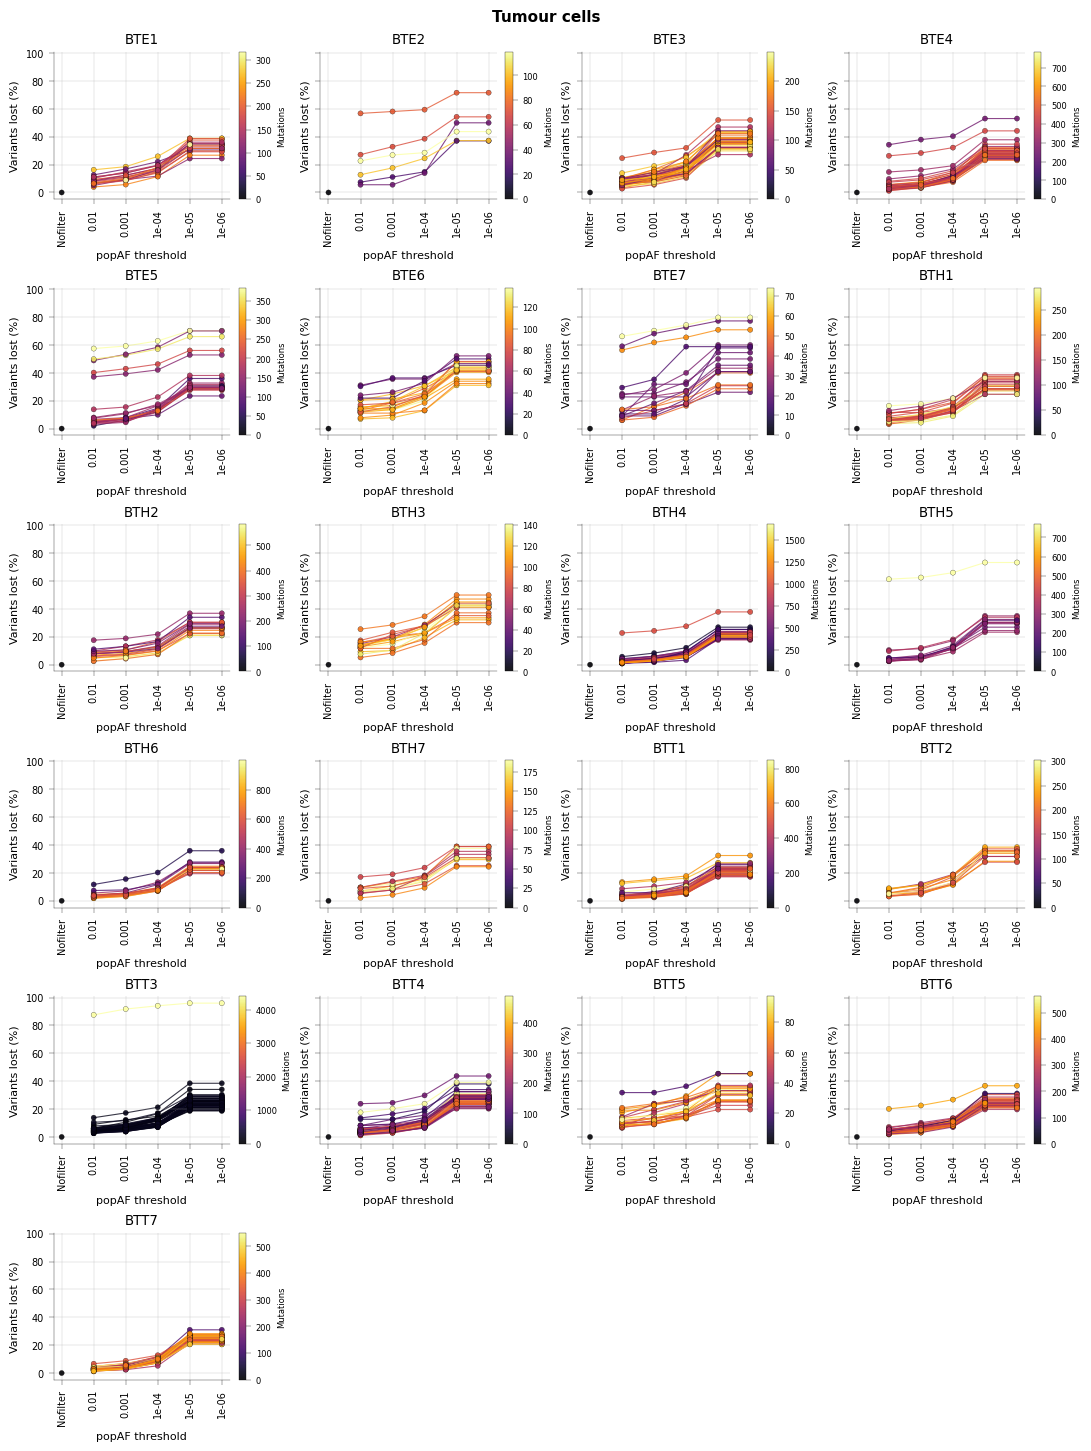

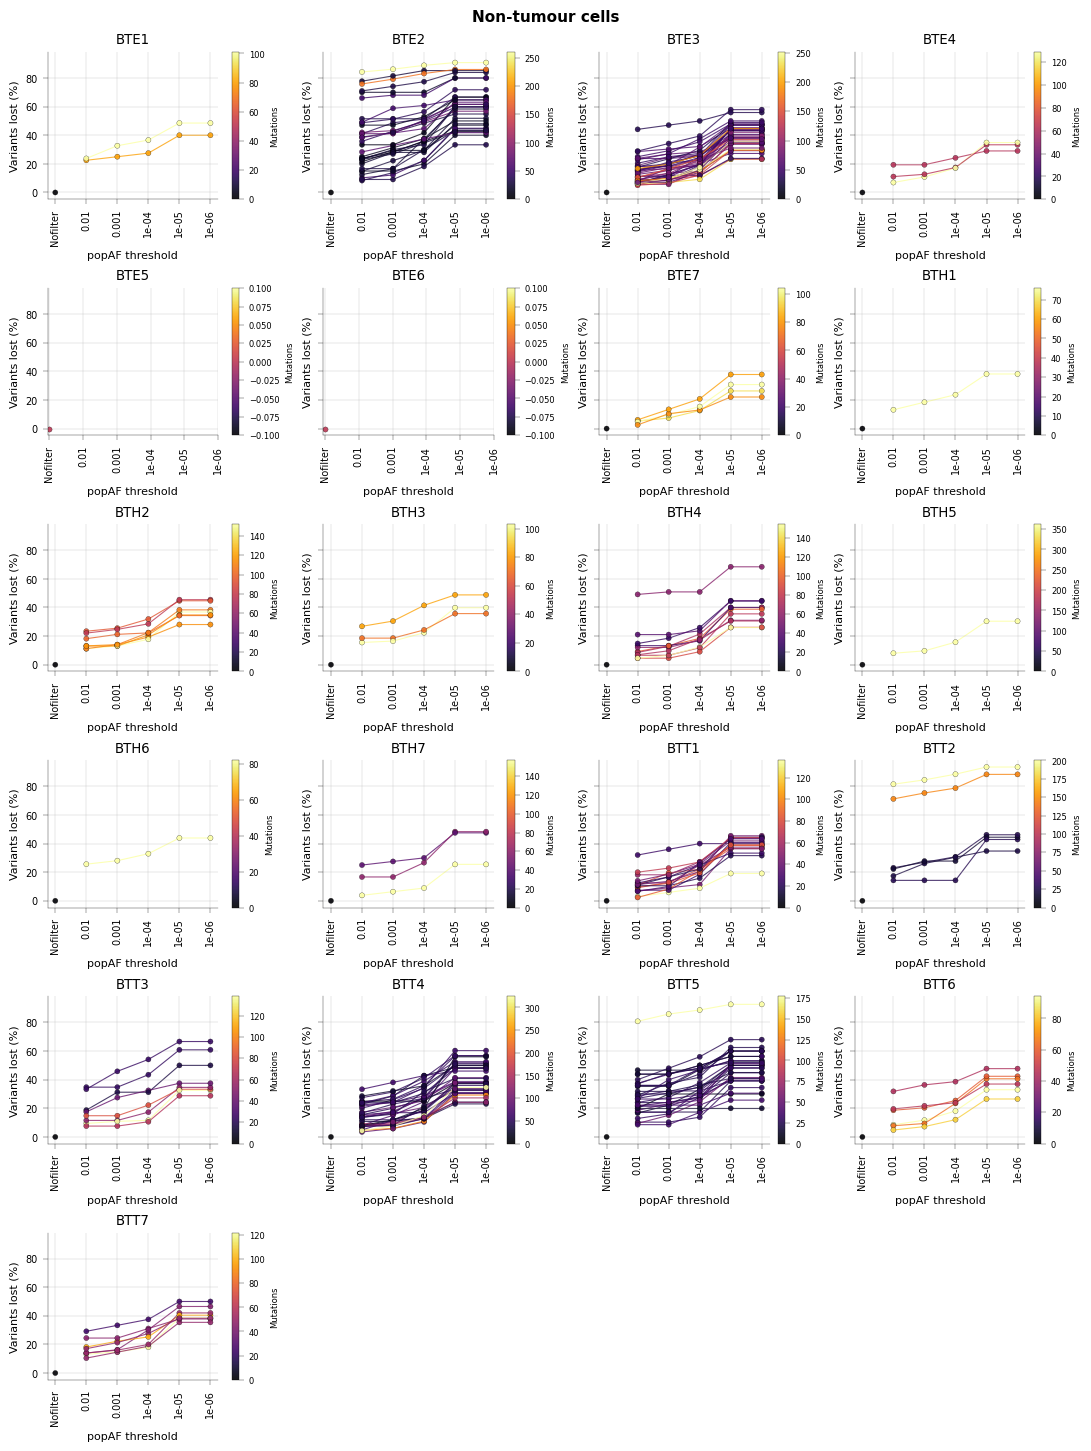

In [3]:
def plot_cells(data, out_pdf, label):
    samples = sorted(data["Sample"].unique())
    ncol = 4
    nrow = int(np.ceil(len(samples) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(10.8, 2.4 * nrow),
                             constrained_layout=True, sharey=True)
    axes = np.atleast_1d(axes).flatten()
    for i, s in enumerate(samples):
        d = data[data["Sample"] == s]
        nrm = mcolors.Normalize(vmin=d["n_vars"].min(), vmax=d["n_vars"].max())
        ax = axes[i]
        for c_id in d["Cell"].unique():
            sub = d[d["Cell"] == c_id]
            ax.plot(sub["Threshold Binned"], sub["Percent Lost"],
                    color=CMAP(nrm(sub["n_vars"].iloc[0])), alpha=0.8, lw=0.8, zorder=1)
        sc = ax.scatter(d["Threshold Binned"], d["Percent Lost"], c=d["n_vars"],
                        cmap="inferno", norm=nrm, alpha=0.9, edgecolors="k",
                        linewidths=0.2, s=14, zorder=2)
        ax.set(title=s, xlabel="popAF threshold", ylabel="Variants lost (%)",
               xticks=range(len(THRESHOLD_LABELS)), xticklabels=THRESHOLD_LABELS)
        ax.tick_params(axis="x", labelrotation=90)
        ax.grid(True, which="both", linewidth=0.2, zorder=0)
        nature_axes(ax)
        cb = fig.colorbar(sc, ax=ax); cb.set_label("Mutations", fontsize=6)
        cb.ax.tick_params(labelsize=6, width=0.25); cb.outline.set_linewidth(0.25)
    for j in range(len(samples), len(axes)):
        fig.delaxes(axes[j])
    fig.suptitle(f"{label} cells", fontsize=11, fontweight="bold")
    fig.savefig(out_pdf, format="pdf", bbox_inches="tight")
    plt.show(); plt.close()

plot_cells(df_tumor,  f"{OUT}/germline_decontamination_curves_tumor_cells.pdf",  "Tumour")
plot_cells(df_normal, f"{OUT}/germline_decontamination_curves_normal_cells.pdf", "Non-tumour")

### BTT4 tumour cells at popAF 0.001 (sorted by percent lost)

In [4]:
btt4 = df[(df["Sample"] == "BTT4") & (df["Threshold"] == 0.001) &
          (df["Cell"].isin(all_tumor_cells))]
print(btt4[["Cell", "Percent Lost"]]
      .sort_values("Percent Lost", ascending=False).to_string(index=False))

      Cell  Percent Lost
BTT4_sc047     24.503311
BTT4_sc334     20.289855
BTT4_sc319     16.504854
BTT4_sc035     12.676056
BTT4_sc017     12.592593
BTT4_sc108      9.259259
BTT4_sc312      9.004739
BTT4_sc345      8.695652
BTT4_sc214      7.643312
BTT4_sc028      7.575758
BTT4_sc336      7.303371
BTT4_sc341      7.142857
BTT4_sc308      7.046980
BTT4_sc322      7.031250
BTT4_sc004      6.976744
BTT4_sc033      6.936416
BTT4_sc104      6.765328
BTT4_sc323      6.744868
BTT4_sc321      6.734007
BTT4_sc003      6.569343
BTT4_sc337      6.557377
BTT4_sc340      6.547619
BTT4_sc303      6.521739
BTT4_sc338      6.372549
BTT4_sc339      6.060606
BTT4_sc311      5.769231
BTT4_sc316      5.726872
BTT4_sc309      5.590062
BTT4_sc314      5.485232
BTT4_sc327      5.367232
BTT4_sc102      5.329154
BTT4_sc317      5.279503
BTT4_sc315      5.217391
BTT4_sc344      5.166052
BTT4_sc333      5.121294
BTT4_sc332      5.090909
BTT4_sc029      5.047319
BTT4_sc128      5.045872
BTT4_sc326      4.980843
